# Taller 1 - Transformaciones Básicas en Computación Visual - Python

* Crear una figura 2D con puntos o formas
* Aplicar traslación, rotación y escala usando matrices de transformación
* Generar una animación (usando bucles o interpolación)
* Animar la transformación en función del tiempo (t) o del frame
* Exportar como GIF animado con imageio

In [2]:
!pip install matplotlib numpy imageio


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import imageio

# Crear una figura 2D con puntos o formas
Para crear una figura 2D, puedes usar la biblioteca `matplotlib` para dibujar puntos o formas. Aquí hay un ejemplo de cómo crear un cuadrado conformado por cuatro puntos:

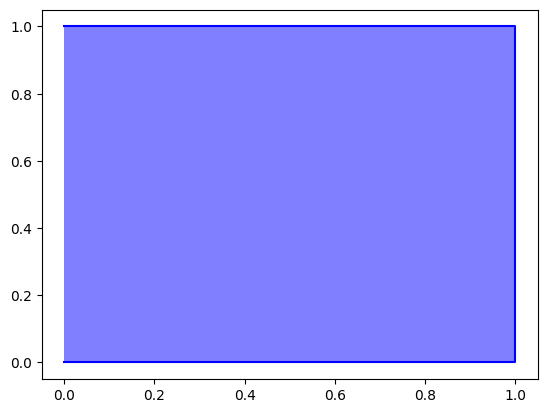

In [15]:
# Crear una figura 2D con puntos o formas
## Se definen los puntos de la figura
P = np.array([[0, 0],
                   [1, 0],
                   [1, 1],
                   [0, 1]])
fig, ax = plt.subplots()
# Dibujar la figura original
ax.plot(P[:, 0], P[:, 1], 'b-', label='Original')
ax.fill(P[:, 0], P[:, 1], 'b', alpha=0.5)
plt.show()


# Aplicar traslación, rotación y escala usando matrices de transformación
Para aplicar transformaciones como traslación, rotación y escala, puedes usar matrices de transformación. Aquí hay un ejemplo de cómo crear una matriz de transformación para cada tipo de transformación

## Traslación
La función `translate` aplica una traslación a un conjunto de puntos en un espacio bidimensional utilizando matrices de transformación homogéneas. La traslación se define mediante los parámetros $ t_x $ y $ t_y $ , que representan los desplazamientos en los ejes $ x $ e $ y $, respectivamente.

1. **Matriz de traslación**:  
    La matriz de traslación homogénea se define como:  
    $$
    T = \begin{bmatrix}
    1 & 0 & t_x \\
    0 & 1 & t_y \\
    0 & 0 & 1
    \end{bmatrix}
    $$

2. **Conversión a coordenadas homogéneas**:  
    Los puntos originales se convierten a coordenadas homogéneas añadiendo un $ 1 $ como tercer componente a cada punto:  
    $$
    P_{\text{homogéneo}} = \begin{bmatrix}
    x_1 & y_1 & 1 \\
    x_2 & y_2 & 1 \\
    \vdots & \vdots & \vdots \\
    x_n & y_n & 1
    \end{bmatrix}
    $$

3. **Aplicación de la transformación**:  
    La traslación se realiza multiplicando los puntos homogéneos por la matriz de traslación:  
    $$
    P' = P_{\text{homogéneo}} \cdot T^T
    $$

4. **Conversión de vuelta a coordenadas cartesianas**:  
    Finalmente, se eliminan las coordenadas homogéneas para obtener los puntos trasladados en el espacio bidimensional:  
    $$
    P'_{\text{cartesiano}} = \begin{bmatrix}
    x'_1 & y'_1 \\
    x'_2 & y'_2 \\
    \vdots & \vdots \\
    x'_n & y'_n
    \end{bmatrix}
    $$

In [16]:
def translate(P, t_x, t_y):
    T = np.array([[1, 0, t_x],
                  [0, 1, t_y],
                  [0, 0, 1]])
    P_homogeneous = np.hstack((P, np.ones((P.shape[0], 1))))
    translated_points = P_homogeneous @ T.T
    return translated_points[:, :2]

* `hstack` de `numpy` se utiliza para apilar horizontalmente arreglos.
* `ones` de `numpy` se utiliza para crear un arreglo de unos. Utiliza como argumento una tupla con la forma del arreglo.
* `@` de `numpy` se utiliza para multiplicar matrices.

## Ejemplo matemático
Supongamos que tenemos un conjunto de puntos $ P = \{(0, 0), (1, 0), (0, 1), (1, 1)\} $ y queremos trasladarlos $ t_x = 2 $ unidades en el eje $ x $ y $ t_y = 3 $ unidades en el eje $ y $. La matriz de traslación sería:
$$
T = \begin{bmatrix}
1 & 0 & 2 \\
0 & 1 & 3 \\
0 & 0 & 1
\end{bmatrix}
$$
Los puntos originales en coordenadas homogéneas serían:
$$
P_{\text{homogéneo}} = \begin{bmatrix}
0 & 0 & 1 \\
1 & 0 & 1 \\
0 & 1 & 1 \\
1 & 1 & 1
\end{bmatrix}
$$
Multiplicando por la matriz de traslación:
$$
P' = P_{\text{homogéneo}} \cdot T^T = \begin{bmatrix}
2 & 3 & 1 \\
3 & 3 & 1 \\
2 & 4 & 1 \\
3 & 4 & 1
\end{bmatrix}
$$
Finalmente, eliminando la última columna, obtenemos los puntos trasladados:
$$
P'_{\text{cartesiano}} = \begin{bmatrix}
2 & 3 \\
3 & 3 \\
2 & 4 \\
3 & 4
\end{bmatrix}
$$

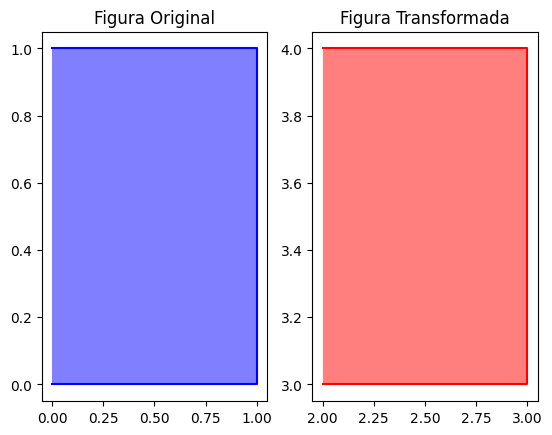

In [17]:
# Aplicar traslación
translated_points = translate(P, 2, 3)
fig, (ax1, ax2) = plt.subplots(1, 2)
# Dibujar la figura original
ax1.plot(P[:, 0], P[:, 1], 'b-', label='Original')
ax1.fill(P[:, 0], P[:, 1], 'b', alpha=0.5)
ax1.set_title('Figura Original')
# Dibujar la figura transformada
ax2.plot(translated_points[:, 0], translated_points[:, 1], 'r-', label='Transformada')
ax2.fill(translated_points[:, 0], translated_points[:, 1], 'r', alpha=0.5)
ax2.set_title('Figura Transformada')
# Mostrar la figura
plt.show()


# Rotación
La función `rotate` aplica una rotación a un conjunto de puntos en un espacio bidimensional utilizando matrices de transformación. La rotación se define mediante un ángulo en grados, que se convierte a radianes para realizar los cálculos.

1. **Conversión del ángulo a radianes**:  
    El ángulo de rotación, dado en grados, se convierte a radianes utilizando la fórmula:  
    $$
    \theta = \alpha \cdot \frac{\pi}{180}
    $$

2. **Matriz de rotación**:  
    La matriz de rotación bidimensional se define como:  
    $$
    R = \begin{bmatrix}
    \cos(\theta) & -\sin(\theta) \\
    \sin(\theta) & \cos(\theta)
    \end{bmatrix}
    $$

3. **Aplicación de la transformación**:  
    La rotación se realiza multiplicando los puntos originales por la matriz de rotación:  
    $$
    P' = P \cdot R^T
    $$  
    Donde $P$ es la matriz de puntos originales y $P'$ es la matriz de puntos rotados.

4. **Resultado**:  
    La función devuelve los puntos rotados en el espacio bidimensional.


In [18]:
def rotate(P, alpha):
    """Aplica una rotación a un conjunto de puntos."""
    theta = np.radians(alpha)
    R = np.array([[np.cos(theta), -np.sin(theta)],
                                 [np.sin(theta), np.cos(theta)]])
    P_r = P @ R.T
    return P_r

## Ejemplo matemático
Supongamos que tenemos un conjunto de puntos $ P = \{(1, 0), (0, 1), (1, 0), (1, 1)\} $ y queremos rotarlos $ \alpha = 45 $ grados. El ángulo en radianes sería:
$$
\begin{align*}
\theta &= 45 \cdot \frac{\pi}{180} \\
    &= \frac{\pi}{2}
\end{align*}
$$

La matriz de rotación sería:
$$
\begin{align*}
R &= \begin{bmatrix}
\cos(\frac{\pi}{2}) & -\sin(\frac{\pi}{2}) \\
\sin(\frac{\pi}{2}) & \cos(\frac{\pi}{2})
\end{bmatrix} \\
  &= \begin{bmatrix}
0 & -1 \\
1 & 0
\end{bmatrix}
\end{align*}
$$

La traspuesta de la matriz de rotación sería:
$$
R^T = \begin{bmatrix}
0 & 1 \\
-1 & 0
\end{bmatrix}
$$

Multiplicando por la matriz de rotación:
$$
P' = P \cdot R^T = \begin{bmatrix}
1 & 0 \\
0 & 1 \\
1 & 0 \\
1 & 1
\end{bmatrix} \cdot \begin{bmatrix}
0 & 1 \\
-1 & 0
\end{bmatrix} = \begin{bmatrix}
0 & 1 \\
-1 & 0 \\
0 & 1 \\
1 & 1
\end{bmatrix}
$$


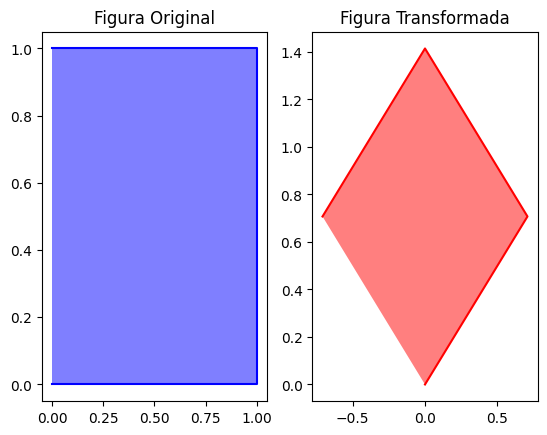

In [19]:
# Aplicar rotación
rotated_points = rotate(P, 45)
# Crear una figura para mostrar las transformaciones
fig, (ax1, ax2) = plt.subplots(1, 2)
# Dibujar la figura original
ax1.plot(P[:, 0], P[:, 1], 'b-', label='Original')
ax1.fill(P[:, 0], P[:, 1], 'b', alpha=0.5)
ax1.set_title('Figura Original')
# Dibujar la figura transformada
ax2.plot(rotated_points[:, 0], rotated_points[:, 1], 'r-', label='Transformada')
ax2.fill(rotated_points[:, 0], rotated_points[:, 1], 'r', alpha=0.5)
ax2.set_title('Figura Transformada')
# Mostrar la figura
plt.show()

# Escala
La función `scale` aplica una escala a un conjunto de puntos en un espacio bidimensional utilizando matrices de transformación. La escala se define mediante los factores $ s_x $ y $ s_y $, que representan los factores de escala en los ejes $ x $ e $ y $, respectivamente.

1. **Matriz de escala**:  
    La matriz de escala bidimensional se define como:  
    $$
    S = \begin{bmatrix}
    s_x & 0 \\
    0 & s_y
    \end{bmatrix}
    $$

2. **Aplicación de la transformación**:  
    La escala se realiza multiplicando los puntos originales por la matriz de escala:  
    $$
    P' = P \cdot S^T
    $$  
    Donde $P$ es la matriz de puntos originales y $P'$ es la matriz de puntos escalados.

3. **Resultado**:  
    La función devuelve los puntos escalados en el espacio bidimensional.

In [13]:
def scale(points, sx, sy):
    """Aplica una escala a un conjunto de puntos."""
    S = np.array([[sx, 0],
                              [0, sy]])
    scaled_points = points @ S.T
    return scaled_points

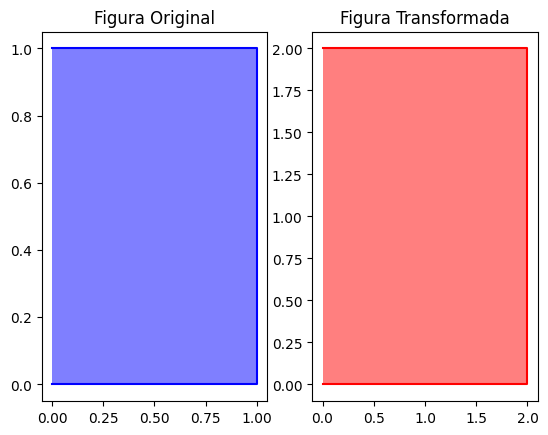

In [21]:
# Aplicar escalaz
scaled_points = scale(P, 2, 2)
# Crear una figura para mostrar las transformaciones
fig, (ax1, ax2) = plt.subplots(1, 2)
# Dibujar la figura original
ax1.plot(P[:, 0], P[:, 1], 'b-', label='Original')
ax1.fill(P[:, 0], P[:, 1], 'b', alpha=0.5)
ax1.set_title('Figura Original')
# Dibujar la figura transformada
ax2.plot(scaled_points[:, 0], scaled_points[:, 1], 'r-', label='Transformada')
ax2.fill(scaled_points[:, 0], scaled_points[:, 1], 'r', alpha=0.5)
ax2.set_title('Figura Transformada')
# Mostrar la figura
plt.show()
